In [1]:
WORD_NUM = 15 # MNRead has 15 words at most per line
penalty = 0.01

# Load in Data

In [5]:
import json
from pathlib import Path
import pandas as pd
import ast
from collections import Counter
from tqdm import tqdm

In [3]:
def count_matches_per_row(row):
    left_side = pd.Series(row['text'].lower().split(' '))
    right_side = pd.Series([i.lower() for i in row['rec_texts']])
    
    counter_left = Counter(left_side.dropna()) # dic
    counter_right = Counter(right_side.dropna())
    
    # 计算两侧相同元素的个数，确保每个元素只计算一次
    matches = sum((counter_left & counter_right).values())
    total = sum(counter_left.values())
    
    # char_level
    counter_left_char = Counter(''.join(left_side.dropna().tolist()))
    counter_right_char = Counter(''.join(right_side.dropna().tolist()))
    matches_char = sum((counter_left_char & counter_right_char).values())
    total_char = sum(counter_left_char.values())
    return [matches, total - matches, total_char-matches_char]


In [4]:
filter_df = pd.read_csv('../../data/human/SelectedFilter.csv')

In [29]:
output_dir = Path("../../filtered/mnread")
gt_dir = Path("../../data/mnread")
files = list(output_dir.rglob('*.*'))
result_li = []
# Load the ground truth COCO JSON (annotations only or full dataset)
with open(gt_dir/"anno.json", "r") as f:
    ground_truth = json.load(f)
# Here we assume ground_truth has a key "annotations"
gt_annotations = ground_truth.get("annotations", [])
img_info = ground_truth.get("images", [])

for model_file in tqdm(files, total=len(files), desc="Rinse model outputs"):
    # Load the model output JSON (replace with your file or object)
    # model_file = output_dir/ "gpt4o.json"
    model_name = model_file.stem
    with open(model_file, "r") as f:
        model_output = json.load(f)

    # Create lookup dictionaries for ground truth annotations and image info by image_id.
    # If there are multiple ground truth annotations per image, you might need to store a list.
    gt_by_chart = {}
    for info, ann in zip(img_info, gt_annotations):
        id = ann["id"]
        full = {}
        full["image_id"] = ann["image_id"]
        full["file_name"] = info["file_name"]
        full["Filter_no"] = info["Filter_no"]
        full["text"] = ann["caption"]
        gt_by_chart.setdefault(id, full)
        
    
    # Now iterate through the model outputs and match with ground truth and image info
    full_out = {}
    for output_item in model_output:
        image_id = output_item["image_id"]
        
        # Optionally, if your model output's "rec_texts" is a string representation of a list,
        # convert it to an actual list.
        rec_texts_str = output_item.get("rec_texts", "")
        try:
            rec_texts = ast.literal_eval(rec_texts_str)
        except Exception:
            rec_texts = rec_texts_str
        output_item["rec_texts"] = rec_texts

        # Retrieve corresponding ground truth annotations (if any)
        gt_matches = gt_by_chart.get(image_id, {})
        chart_no, reso, row_no = Path(gt_matches.get("file_name", " _ _ _")).stem.split("_")
        full_out[image_id] = gt_matches
        full_out[image_id]["rec_texts"] = rec_texts
        full_out[image_id]["chart_no"] = chart_no
        full_out[image_id]["reso"] = reso
        full_out[image_id]["row_no"] = row_no
        
        
    df = pd.DataFrame(full_out.values())
    df = pd.merge(df, filter_df, on='Filter_no', how='inner')

    df[['match','missing','missing_char']] = df.apply(lambda row: count_matches_per_row(row), axis=1).apply(pd.Series)
    df['missing_clipped'] = df['missing'].clip(upper=10)

    group_sum = df.groupby(['chart_no','a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: -0.2 + x['missing_clipped'].sum()*0.01).reset_index()
    group_sum.columns = ['chart_no', 'a', 'b', 'VA', 'CS', 'Cond','acuity']
    group_sum = group_sum.groupby(['a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: x['acuity'].mean()).reset_index()
    group_sum.columns = ['a', 'b', 'VA', 'CS', 'Cond',model_name]
    result_li.append(group_sum)


Rinse model outputs:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_3124246/3500381454.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sum = df.groupby(['chart_no','a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: -0.2 + x['missing_clipped'].sum()*0.01).reset_index()
/tmp/ipykernel_3124246/3500381454.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sum = group_sum.groupby(['a', 'b', '

In [30]:
from functools import reduce
summary_dir = Path("../../data/summary")
reduce(lambda left, right: pd.merge(left, right, on=['a', 'b', 'VA', 'CS', 'Cond']), result_li).to_csv(summary_dir/'mnread.csv', index=False)

In [46]:
import pandas as pd
df1 = reduce(lambda left, right: pd.merge(left, right, on=['a', 'b', 'VA', 'CS', 'Cond']), result_li)
df2 = pd.read_csv(summary_dir/'MNREADSummary_0410.csv')
df_human = pd.read_csv('../../data/human/human_mnread_acuity.csv')

In [ ]:
final_df = pd.merge(pd.merge(df1, df_human, on=['a', 'b'],how='left'), df2, on=['a', 'b'], how='left')
final_df = final_df[['a', 'b', 'VA', 'CS', 'Cond', 'Expected', 'human', 'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']]
final_df

,a,b,VA,CS,Cond,Expected,human,gpt4o,gpt4o_mini,gemini_15_flash,gemini_15_pro,gemini_2_flash,claude3_7_sonnet,claude3_5_haiku,qwen,maerec,spts,ppocr,azure,google
0,0.016,1.000,1.57,1.49,Horizontal,1.57,1.557857,1.800000,1.800000,1.796667,1.800000,1.800000,1.800000,1.800000,1.800000,1.748000,1.748000,1.748000,1.748000,1.748000
1,0.027,0.027,1.57,0.59,Combined,1.57,1.726111,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.749000,1.749000,1.749000,1.749000,1.749000
2,0.031,1.000,1.27,1.67,Horizontal,1.27,0.922381,1.796667,1.796667,1.796667,1.796667,1.800000,1.800000,1.800000,1.800000,1.747667,1.747667,1.747667,1.747667,1.747667
3,0.048,0.048,1.27,0.82,Combined,1.27,1.356111,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,1.748000,1.748000,1.748000,1.748000,1.748000
4,0.063,1.000,0.97,1.85,Horizontal,0.97,0.629524,1.593333,1.656667,1.690000,1.700000,1.653333,1.796667,1.793333,1.796667,1.748667,1.748667,1.741333,1.748667,1.744000
5,0.086,0.086,0.97,1.07,Combined,0.97,0.951111,1.600000,1.610000,1.800000,1.800000,1.720000,1.800000,1.800000,1.800000,1.747000,1.747000,1.747000,1.747000,1.747000
6,0.125,1.000,0.66,1.96,Horizontal,0.66,0.758571,1.260000,1.240000,1.386667,1.390000,1.353333,1.530000,1.546667,1.800000,1.467667,1.737333,1.543667,1.600333,1.507333
7,0.157,0.157,0.66,1.33,Combined,0.66,0.609444,1.290000,1.300000,1.460000,1.450000,1.400000,1.600000,1.700000,1.800000,1.745000,1.745000,1.700000,1.701000,1.600000
8,0.250,1.000,0.36,2.05,Horizontal,0.36,0.364286,0.887500,0.927500,1.060000,1.045000,0.970000,1.162500,1.165000,1.795000,1.205000,1.421250,1.029500,1.116000,1.124500
9,0.288,0.288,0.36,1.59,Combined,0.36,0.265556,0.890000,0.910000,1.080000,1.100000,1.000000,1.310000,1.270000,1.800000,1.219000,1.413000,1.201000,1.138000,1.208000


# Figure

In [ ]:
final_df_fig = final_df.copy()

final_df_fig[['Expected', 'human', 'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']] =  final_df_fig[['Expected', 'human', 'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']]  - final_df_fig.loc[15,['Expected', 'human', 'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']]
final_df.to_csv(summary_dir/'mnread_combined_0330.csv', index=False)

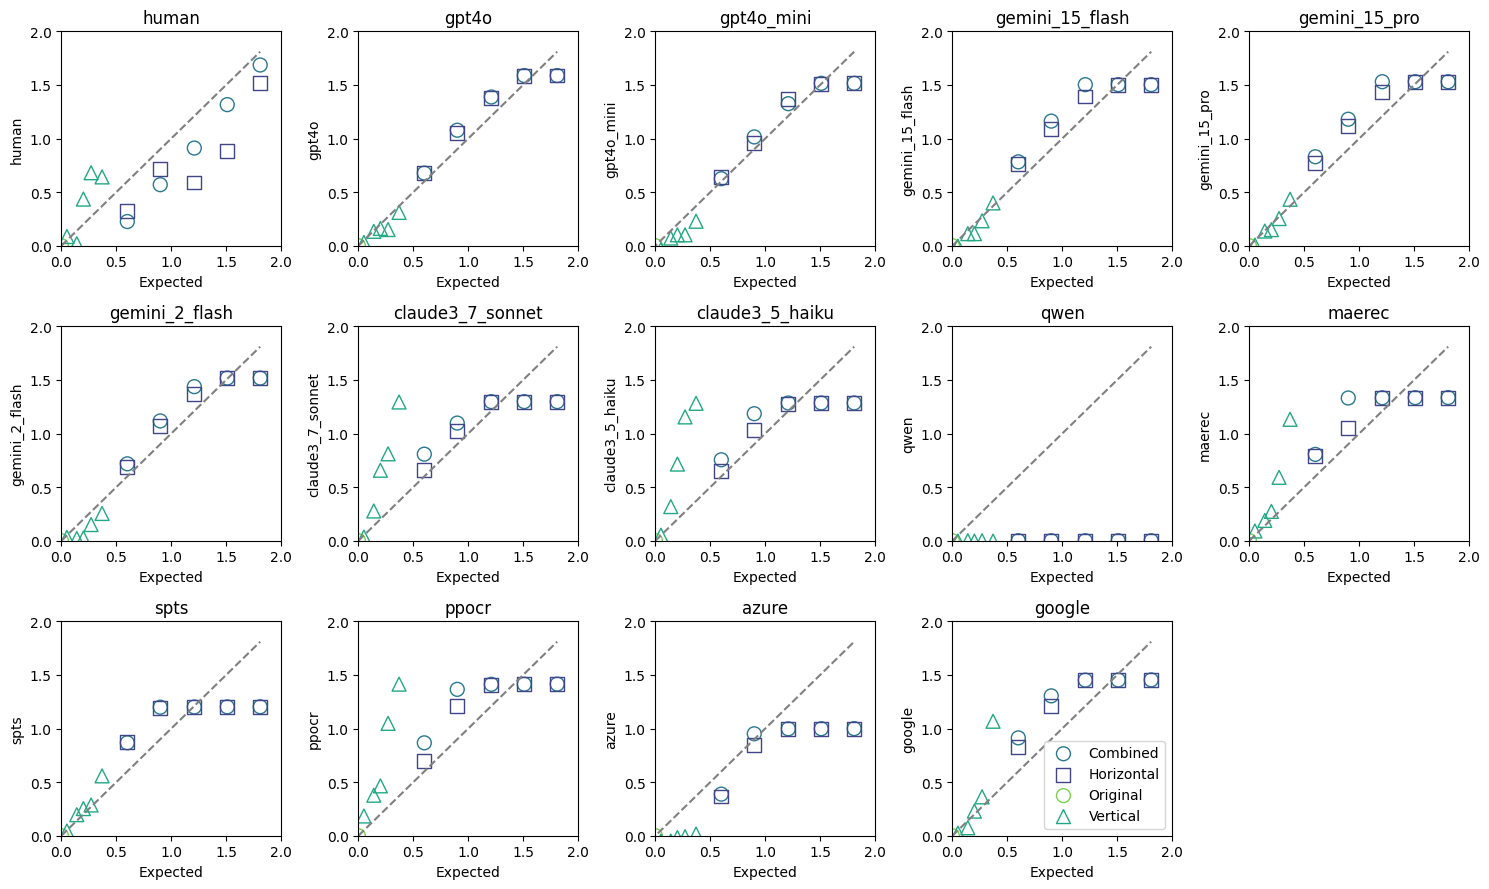

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# Define a function to choose marker based on condition
def get_marker(cond):
    if cond == 'Horizontal':
        return 's'  # hollow square
    elif cond == 'Vertical':
        return '^'  # hollow triangle
    else:
        return 'o'  # hollow circle

# Create a color palette for unique conditions
unique_conditions = final_df_fig['Cond'].unique()
palette = sns.color_palette("viridis", len(unique_conditions))
color_mapping = {cond: palette[i] for i, cond in enumerate(unique_conditions)}

# Define a function to plot a scatter plot on a given axis for a specified model column
def plot_scatter(ax, model_col, df):
    # Plot each group (by Cond) separately to assign markers and colors
    for cond, group in df.groupby('Cond'):
        marker = get_marker(cond)
        ax.scatter(
            group['Expected'],
            group[model_col],
            label=cond,
            marker=marker,
            facecolors='none',  # makes marker hollow
            edgecolors=color_mapping[cond],
            s=100  # marker size
        )
    
    # Add a dashed diagonal line that spans the range of the data
    x_vals = df['Expected']
    y_vals = df[model_col]
    overall_min = min(x_vals.min(), y_vals.min())
    overall_max = max(x_vals.max(), y_vals.max())
    ax.plot([overall_min, overall_max], [overall_min, overall_max],
            linestyle='--', color='grey')
    
    # Set labels, title and legend
    ax.set_xlabel("Expected")
    ax.set_ylabel(model_col)
    ax.set_xlim(0, 2.0)
    ax.set_ylim(0, 2.0)
    ax.set_title(f"{model_col}")
    # ax.legend()

# List of models to plot (include 'human' and other models)
models = ['human', 'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']

# Determine subplot grid layout; here we choose 2 columns
num_models = len(models)
ncols = 5
nrows = math.ceil(num_models / ncols)
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
# If there's only one subplot, axes is not an array; make it a list for consistency.
if num_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot each model in its corresponding subplot
for i, model in enumerate(models):
    plot_scatter(axes[i], model, final_df_fig)

# Remove any extra subplots if the grid has more axes than models
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.legend()
plt.tight_layout()
plt.show()

# # Plot for 'human'
# for model in models:
#     plot_scatter(model, final_df_fig)

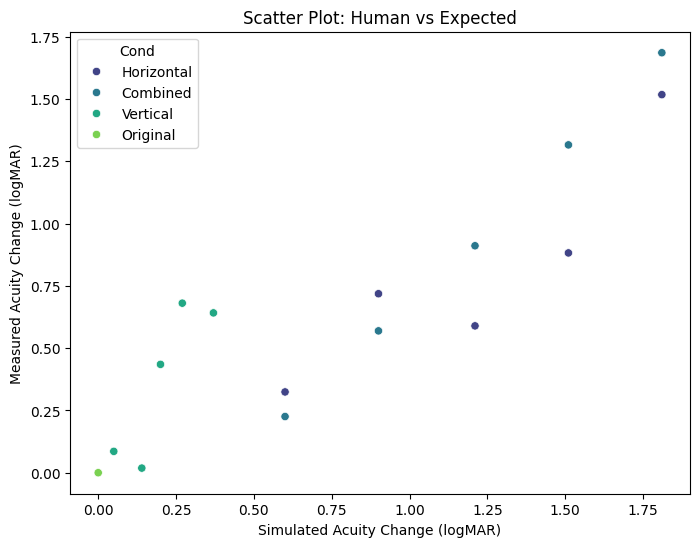

In [ ]:



# Plot for human
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df_fig, x='Expected', y='human', hue='Cond', palette='viridis')
plt.title("Scatter Plot: Human vs Expected")
plt.xlabel("Simulated Acuity Change (logMAR)")
plt.ylabel("Measured Acuity Change (logMAR)")
plt.legend(title="Cond")
plt.show()



In [ ]:
# List of other model columns (adjust this list as needed)
other_models = [
    "gpt4o", "gpt4o_mini", "gemini_15_flash", "gemini_15_pro", 
    "gemini_2_flash", "claude3_7_sonnet", "claude3_5_haiku", 
    "qwen", "maerec", "spts", "ppocr", "azure", "google"
]

# Create separate figures for each of the other models
for model in other_models:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='Expected', y=model, hue='Cond', palette='viridis')
    plt.title(f"Scatter Plot: {model} vs Expected")
    plt.xlabel("Expected")
    plt.ylabel(model)
    plt.legend(title="Cond")
    plt.show()

# Archive

In [ ]:
# Create lookup dictionaries for ground truth annotations and image info by image_id.
# If there are multiple ground truth annotations per image, you might need to store a list.
gt_by_chart = {}
for info, ann in zip(img_info, gt_annotations):
    id = ann["id"]
    full = {}
    full["image_id"] = ann["image_id"]
    full["file_name"] = info["file_name"]
    full["Filter_no"] = info["Filter_no"]
    full["text"] = ann["caption"]
    gt_by_chart.setdefault(id, full)


In [ ]:
import ast
# Now iterate through the model outputs and match with ground truth and image info
full_out = {}
for output_item in model_output:
    image_id = output_item["image_id"]
    
    # Optionally, if your model output's "rec_texts" is a string representation of a list,
    # convert it to an actual list.
    rec_texts_str = output_item.get("rec_texts", "")
    try:
        rec_texts = ast.literal_eval(rec_texts_str)
    except Exception:
        rec_texts = rec_texts_str
    output_item["rec_texts"] = rec_texts

    # Retrieve corresponding ground truth annotations (if any)
    gt_matches = gt_by_chart.get(image_id, {})
    chart_no, reso, row_no = Path(gt_matches.get("file_name", "___")).stem.split("_")
    full_out[image_id] = gt_matches
    full_out[image_id]["rec_texts"] = rec_texts
    full_out[image_id]["chart_no"] = chart_no
    full_out[image_id]["reso"] = reso
    full_out[image_id]["row_no"] = row_no
    
    

In [ ]:
from collections import Counter
import pandas as pd

def count_matches_per_row(row):
    left_side = pd.Series(row['text'].lower().split(' '))
    right_side = pd.Series([i.lower() for i in row['rec_texts']])
    
    counter_left = Counter(left_side.dropna()) # dic
    counter_right = Counter(right_side.dropna())
    
    # 计算两侧相同元素的个数，确保每个元素只计算一次
    matches = sum((counter_left & counter_right).values())
    total = sum(counter_left.values())
    
    # char_level
    counter_left_char = Counter(''.join(left_side.dropna().tolist()))
    counter_right_char = Counter(''.join(right_side.dropna().tolist()))
    matches_char = sum((counter_left_char & counter_right_char).values())
    total_char = sum(counter_left_char.values())
    return [matches, total - matches, total_char-matches_char]


In [ ]:

df = pd.DataFrame(full_out.values())
df = pd.merge(df, filter_df, on='Filter_no', how='inner')
# df['text'].str.split(" ", expand=True)
# # Split the 'text' column into separate columns using space as the delimiter
# split_text = df['text'].str.split(" ", expand=True)

# # Rename the split columns to L1, L2, ..., Ln
# split_text.columns = [f"L{i+1}" for i in range(split_text.shape[1])]

# # Concatenate the new columns back to the original DataFrame
# df = pd.concat([df, split_text], axis=1)
df[['match','missing','missing_char']] = df.apply(lambda row: count_matches_per_row(row), axis=1).apply(pd.Series)
df['missing_clipped'] = df['missing'].clip(upper=10)

group_sum = df.groupby(['chart_no','a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: -0.2 + x['missing_clipped'].sum()*penalty).reset_index()
group_sum.columns = ['chart_no', 'a', 'b', 'VA', 'CS', 'Cond','acuity']
group_sum = group_sum.groupby(['a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: x['acuity'].mean()).reset_index()
group_sum.columns = ['a', 'b', 'VA', 'CS', 'Cond',model_name]
group_sum
# df_merged = pd.merge(df, group_sum, on='chart_no', how='left')
# df_merged = df_merged[['image_id', 'file_name', 'Filter_no', 'text', 'rec_texts', 'chart_no',
#                        'row_no', 'a', 'b', 'VA', 'CS', 'Cond', 'acuity']]
# df_merged

/tmp/ipykernel_2338998/3606988138.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sum = df.groupby(['chart_no','a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: -0.2 + x['missing_clipped'].sum()*0.01).reset_index()
/tmp/ipykernel_2338998/3606988138.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sum = group_sum.groupby(['a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: x['acuity'].mean()).re

,a,b,VA,CS,Cond,gpt4o
0,0.016,1.000,1.57,1.49,Horizontal,1.796667
1,0.027,0.027,1.57,0.59,Combined,1.800000
2,0.031,1.000,1.27,1.67,Horizontal,1.766667
3,0.048,0.048,1.27,0.82,Combined,1.790000
4,0.063,1.000,0.97,1.85,Horizontal,1.556667
5,0.086,0.086,0.97,1.07,Combined,1.560000
6,0.125,1.000,0.66,1.96,Horizontal,1.253333
7,0.157,0.157,0.66,1.33,Combined,1.390000
8,0.250,1.000,0.36,2.05,Horizontal,0.957500
9,0.288,0.288,0.36,1.59,Combined,1.000000
